# Freight Rate Prediction    

In [ ]:
import pandas as pd     
import numpy as np 
import os

df=pd.read_csv('data/train-test.csv')
print(df.head(5))
df.shape

     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     Baltimore    38.09122   -76.78906   
1  TR-000002      Richmond  Philadelphia    38.09122   -76.78906   
2  TR-000003  Philadelphia     Green Bay    39.22317   -72.96710   
3  TR-000004      Hartford       Atlanta    39.55328   -72.18051   
4  TR-000005        Dallas     Nashville    31.83025   -94.38343   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      38.16908     -72.74564     274.3   Dry Van  30658.0  2025-01-01   
1      39.22317     -72.96710     280.5    Reefer  17555.0  2025-01-01   
2      44.30296     -87.52871     967.8   Dry Van  31721.0  2025-01-01   
3      34.84933     -86.28940     965.4   Dry Van  32333.0  2025-01-01   
4      35.29479     -88.08915     541.9    Reefer  35183.0  2025-01-01   

   market_index  quote_signal  posted_rate  
0       0.95684       2.39595       645.41  
1       0.97623       2.43355       679.97  
2       1.0

(48000, 14)

In [45]:
df.dtypes

load_id             str
pickup              str
delivery            str
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment           str
weight          float64
date                str
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

In [46]:
df.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [47]:
print("Duplicate load_id:", df.load_id.duplicated().sum())
print("Equipment values:", df.equipment.unique())
print("Unique pickups:", df.pickup.nunique(), "| Unique deliveries:", df.delivery.nunique())

Duplicate load_id: 0
Equipment values: <StringArray>
['Dry Van', 'Reefer', 'Flatbed']
Length: 3, dtype: str
Unique pickups: 64 | Unique deliveries: 64


In [48]:
print("Date range:", df.date.min(), "to", df.date.max())
print("Unique dates:", df.date.nunique())

Date range: 2025-01-01 to 2025-10-31
Unique dates: 304


In [49]:
df[['distance','weight','market_index','quote_signal','posted_rate']].describe()

,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [50]:
print('Negative weight rows:', (df.weight<0).sum())
df.loc[df.weight<0,'weight'].describe()

Negative weight rows: 292


count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [51]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['haversine'] = haversine(df.pickup_lat, df.pickup_lon, df.delivery_lat, df.delivery_lon)
df['ratio'] = df.distance / df.haversine
df['ratio'].describe()

count    48000.000000
mean         1.194681
std          0.143541
min          1.058090
25%          1.164765
50%          1.182231
75%          1.204765
max          9.634919
Name: ratio, dtype: float64

In [52]:
df.sort_values('ratio', ascending=False)[['pickup','delivery','distance','haversine','ratio']].head(10)

,pickup,delivery,distance,haversine,ratio
11949,Shreveport,New Orleans,70.0,7.26524,9.634919
12480,New Orleans,Shreveport,70.0,7.26524,9.634919
15756,Shreveport,New Orleans,70.0,7.26524,9.634919
6960,New Orleans,Shreveport,70.0,7.26524,9.634919
37183,Shreveport,New Orleans,70.0,7.26524,9.634919
38469,Shreveport,New Orleans,70.0,7.26524,9.634919
4140,New Orleans,Shreveport,70.0,7.26524,9.634919
16351,New Orleans,Shreveport,70.0,7.26524,9.634919
46059,Shreveport,New Orleans,70.0,7.26524,9.634919
34136,Shreveport,New Orleans,70.0,7.26524,9.634919


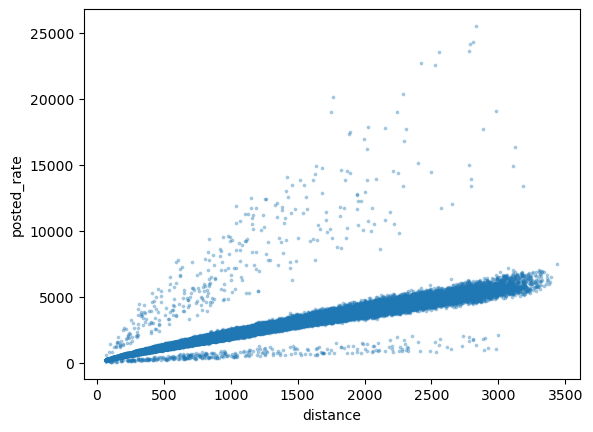

In [53]:
import matplotlib.pyplot as plt
plt.scatter(df['distance'], df['posted_rate'], s=3, alpha=0.3)
plt.xlabel('distance')
plt.ylabel('posted_rate')
plt.show()

In [54]:
df['rate_per_mile'] = df.posted_rate / df.distance
df['rate_per_mile'].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

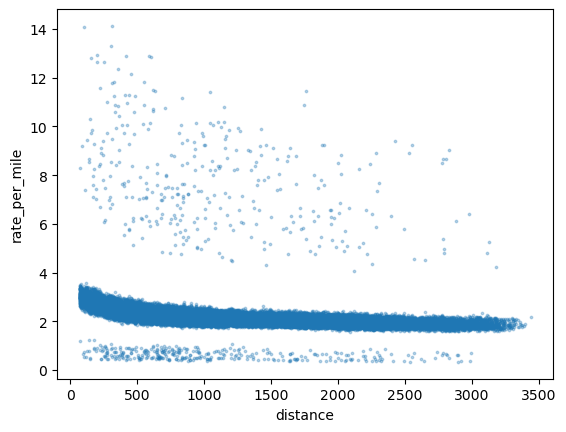

In [55]:
plt.scatter(df['distance'], df['rate_per_mile'], s=3, alpha=0.3)
plt.xlabel('distance'); plt.ylabel('rate_per_mile')
plt.show()

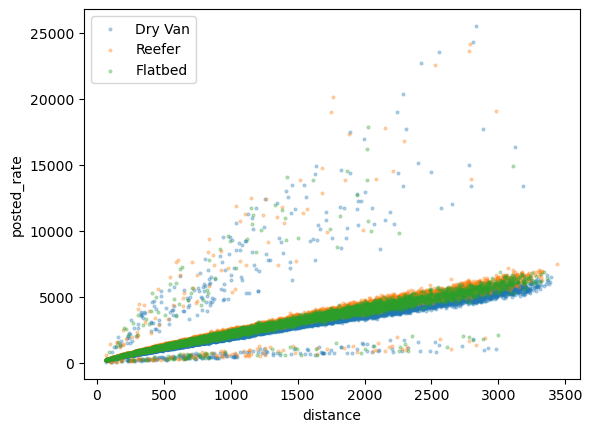

In [56]:
for eq in df.equipment.unique():
    sub = df[df.equipment==eq]
    plt.scatter(sub['distance'], sub['posted_rate'], s=4, alpha=0.3, label=eq)
plt.xlabel('distance'); plt.ylabel('posted_rate'); plt.legend()
plt.show()

In [57]:
df[['rate_per_mile','market_index','quote_signal']].corr()

,rate_per_mile,market_index,quote_signal
rate_per_mile,1.000000,0.083478,0.049342
market_index,0.083478,1.000000,-0.067827
quote_signal,0.049342,-0.067827,1.000000


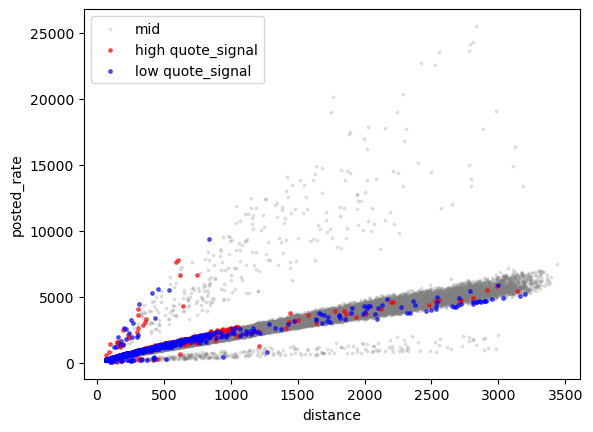

In [58]:
high = df[df.quote_signal > df.quote_signal.quantile(0.95)]
low = df[df.quote_signal < df.quote_signal.quantile(0.05)]
rest = df[(df.quote_signal <= df.quote_signal.quantile(0.95)) & (df.quote_signal >= df.quote_signal.quantile(0.05))]

plt.scatter(rest['distance'], rest['posted_rate'], s=3, alpha=0.2, color='gray', label='mid')
plt.scatter(high['distance'], high['posted_rate'], s=6, alpha=0.6, color='red', label='high quote_signal')
plt.scatter(low['distance'], low['posted_rate'], s=6, alpha=0.6, color='blue', label='low quote_signal')
plt.xlabel('distance'); plt.ylabel('posted_rate'); plt.legend()
plt.show()

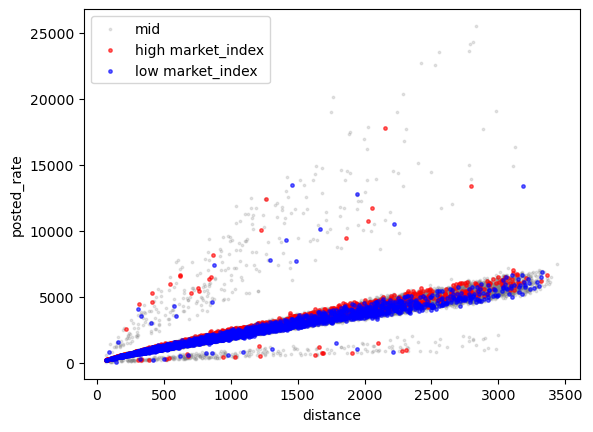

In [59]:
high = df[df.market_index > df.market_index.quantile(0.95)]
low = df[df.market_index < df.market_index.quantile(0.05)]
rest = df[(df.market_index <= df.market_index.quantile(0.95)) & (df.market_index >= df.market_index.quantile(0.05))]

plt.scatter(rest['distance'], rest['posted_rate'], s=3, alpha=0.2, color='gray', label='mid')
plt.scatter(high['distance'], high['posted_rate'], s=6, alpha=0.6, color='red', label='high market_index')
plt.scatter(low['distance'], low['posted_rate'], s=6, alpha=0.6, color='blue', label='low market_index')
plt.xlabel('distance'); plt.ylabel('posted_rate'); plt.legend()
plt.show()

In [60]:
val = pd.read_csv('data/validation.csv')
print(val.isna().sum())
print((val.weight < 0).sum())

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64
145


In [61]:
print("Val Data Date Range:", val.date.min(),"to", val.date.max())

Val Data Date Range: 2025-11-01 to 2025-12-31


In [62]:
df.groupby('equipment')['weight'].median()

equipment
Dry Van    31373.0
Flatbed    31462.5
Reefer     31524.0
Name: weight, dtype: float64

In [63]:
def clean(df, weight_median=None, market_median=None):
    df = df.copy()
    df['weight'] = df['weight'].abs()
    
    if weight_median is None:
        weight_median = df['weight'].median()
    if market_median is None:
        market_median = df['market_index'].median()
    
    df['weight'] = df['weight'].fillna(weight_median)
    df['market_index'] = df['market_index'].fillna(market_median)
    
    return df, weight_median, market_median

In [64]:
df['date'] = pd.to_datetime(df['date'])

train_raw = df[df['date'] < '2025-09-01']
test_raw  = df[df['date'] >= '2025-09-01']

print(train_raw.shape, test_raw.shape)

(38477, 17) (9523, 17)


In [65]:
train, w_med, m_med = clean(train_raw)
test, _, _ = clean(test_raw, weight_median=w_med, market_median=m_med)

print(train.isna().sum().sum(), test.isna().sum().sum())  # should be 0, 0
print("weight median used:", w_med, "| market_index median used:", m_med)

0 0
weight median used: 31472.5 | market_index median used: 1.12


In [66]:
def add_date_features(df):
    df = df.copy()
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    return df

train = add_date_features(train)
test = add_date_features(test)

In [67]:
train = pd.get_dummies(train, columns=['equipment'], prefix='eq')
test = pd.get_dummies(test, columns=['equipment'], prefix='eq')

# align columns in case a category is missing in one split
test = test.reindex(columns=train.columns, fill_value=0)

In [68]:
def target_encode(train, test, col, target='posted_rate'):
    means = train.groupby(col)[target].mean()
    global_mean = train[target].mean()
    print(means)
    train[col + '_enc'] = train[col].map(means)
    test[col + '_enc'] = test[col].map(means).fillna(global_mean)
    return train, test


train, test = target_encode(train, test, 'pickup')
train, test = target_encode(train, test, 'delivery')

pickup
Albany         2935.423798
Albuquerque    2863.004060
Amarillo       2595.161292
Atlanta        1763.696784
Austin         2432.802416
                  ...     
Tampa          2156.696413
Toledo         2038.639268
Tucson         3317.441836
Tulsa          2011.682340
Washington     2290.018231
Name: posted_rate, Length: 64, dtype: float64
delivery
Albany         2931.613441
Albuquerque    2925.361726
Amarillo       2657.285687
Atlanta        1811.160238
Austin         2386.846704
                  ...     
Tampa          2279.063915
Toledo         2024.417172
Tucson         3330.075259
Tulsa          1946.561171
Washington     2200.277053
Name: posted_rate, Length: 64, dtype: float64


In [69]:
train.head(5)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,...,ratio,rate_per_mile,month,day_of_week,day_of_year,eq_Dry Van,eq_Flatbed,eq_Reefer,pickup_enc,delivery_enc
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,...,1.247903,2.352935,1,2,1,True,False,False,2315.212083,2694.684715
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,...,1.271961,2.424135,1,2,1,False,False,True,2315.212083,2519.516893
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,...,1.170367,1.862513,1,2,1,True,False,False,2479.178372,2163.129682
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,...,1.148546,1.892770,1,2,1,True,False,False,2667.137602,1811.160238
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,...,1.248148,2.547112,1,2,1,False,False,True,2170.023524,1780.952665


In [70]:
train.dtypes

load_id                     str
pickup                      str
delivery                    str
pickup_lat              float64
pickup_lon              float64
delivery_lat            float64
delivery_lon            float64
distance                float64
weight                  float64
date             datetime64[us]
market_index            float64
quote_signal            float64
posted_rate             float64
haversine               float64
ratio                   float64
rate_per_mile           float64
month                     int32
day_of_week               int32
day_of_year               int32
eq_Dry Van                 bool
eq_Flatbed                 bool
eq_Reefer                  bool
pickup_enc              float64
delivery_enc            float64
dtype: object

In [71]:
feature_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'weight', 'market_index', 'quote_signal',
    'month', 'day_of_week', 'day_of_year',
    'eq_Dry Van', 'eq_Flatbed', 'eq_Reefer',
    'pickup_enc', 'delivery_enc'
]

X_train = train[feature_cols]
y_train = train['posted_rate']

X_test = test[feature_cols]
y_test = test['posted_rate']

print(X_train.shape, X_test.shape)

(38477, 16) (9523, 16)


In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

MAE: 139.88
RMSE: 638.00
R2: 0.8252


In [73]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbr = HistGradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

mae = mean_absolute_error(y_test, pred_gbr)
rmse = np.sqrt(mean_squared_error(y_test, pred_gbr))
r2 = r2_score(y_test, pred_gbr)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

MAE: 127.70
RMSE: 635.86
R2: 0.8264


In [74]:
residuals = y_test - pred_gbr
errors_df = test.copy()
errors_df['abs_error'] = residuals.abs()
errors_df.sort_values('abs_error', ascending=False)[['distance','eq_Dry Van', 'eq_Flatbed', 'eq_Reefer','posted_rate']].head(15)


,distance,eq_Dry Van,eq_Flatbed,eq_Reefer,posted_rate
40096,1760.3,False,False,True,20132.37
40171,2283.4,True,False,False,20361.89
43539,1893.0,True,False,False,17514.11
46213,2023.4,False,True,False,17893.17
47298,2979.1,False,False,True,19110.30
40322,1639.9,True,False,False,14949.25
46516,1684.3,False,False,True,14784.38
42881,1460.5,True,False,False,13503.63
42149,1415.5,True,False,False,13026.22
46366,2251.9,True,False,False,14403.14


In [75]:
errors_df['abs_error'].sort_values(ascending=False).head(15)

40096    16191.255531
40171    15903.671165
43539    13661.040682
46213    13652.966636
47298    13093.600468
40322    11681.376942
46516    11242.470227
42881    10527.652314
42149    10173.803507
46366    10008.136993
44267     9961.735203
47536     9688.191195
43302     9390.312501
43384     9314.761749
42735     9305.940298
Name: abs_error, dtype: float64

In [76]:
y_train_log = np.log1p(y_train)

gbr_log = HistGradientBoostingRegressor(random_state=42)
gbr_log.fit(X_train, y_train_log)

pred_log = gbr_log.predict(X_test)
pred_gbr_log = np.expm1(pred_log)  

mae = mean_absolute_error(y_test, pred_gbr_log)
rmse = np.sqrt(mean_squared_error(y_test, pred_gbr_log))
r2 = r2_score(y_test, pred_gbr_log)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

MAE: 118.32
RMSE: 635.71
R2: 0.8265


In [77]:
train2_raw = train[train['date'] < '2025-07-01']
val2_raw   = train[train['date'] >= '2025-07-01']

X_train2 = train2_raw[feature_cols]
y_train2 = np.log1p(train2_raw['posted_rate'])

X_val2 = val2_raw[feature_cols]
y_val2 = val2_raw['posted_rate']  # keep in dollars for scoring

print(X_train2.shape, X_val2.shape)

(28806, 16) (9671, 16)


In [78]:
from itertools import product

param_grid = {
    'max_iter': [100, 200],
    'max_depth': [None, 6],
    'learning_rate': [0.1, 0.05],
}

results = []
for max_iter, max_depth, lr in product(param_grid['max_iter'], param_grid['max_depth'], param_grid['learning_rate']):
    model = HistGradientBoostingRegressor(
        max_iter=max_iter, max_depth=max_depth, learning_rate=lr, random_state=42
    )
    model.fit(X_train2, y_train2)
    pred = np.expm1(model.predict(X_val2))
    rmse = np.sqrt(mean_squared_error(y_val2, pred))
    mae = mean_absolute_error(y_val2, pred)
    results.append((max_iter, max_depth, lr, mae, rmse))

results_df = pd.DataFrame(results, columns=['max_iter','max_depth','learning_rate','mae','rmse'])
results_df.sort_values('rmse')

,max_iter,max_depth,learning_rate,mae,rmse
1,100,NaN,0.05,143.039795,627.614377
3,100,6.0,0.05,145.872045,628.325445
0,100,NaN,0.10,154.364829,631.606140
4,200,NaN,0.10,154.364829,631.606140
5,200,NaN,0.05,161.129211,633.900223
7,200,6.0,0.05,163.273230,635.976036
2,100,6.0,0.10,173.783876,643.129981
6,200,6.0,0.10,173.783876,643.129981


In [79]:
final_model = HistGradientBoostingRegressor(
    max_iter=100, max_depth=None, learning_rate=0.05, random_state=42
)
final_model.fit(X_train, np.log1p(y_train))

pred_final = np.expm1(final_model.predict(X_test))

mae = mean_absolute_error(y_test, pred_final)
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
r2 = r2_score(y_test, pred_final)

print(f"Final MAE: {mae:.2f}")
print(f"Final RMSE: {rmse:.2f}")
print(f"Final R2: {r2:.4f}")

Final MAE: 119.91
Final RMSE: 637.68
Final R2: 0.8254


#### Hyperparameter tuning (see above) showed no meaningful improvement over defaults, so the final model uses default settings for simplicity

In [ ]:
# Reload full data fresh, clean using stats from the FULL dataset 
full_raw = pd.read_csv('data/train-test.csv')
full_raw['date'] = pd.to_datetime(full_raw['date'])

full, full_w_med, full_m_med = clean(full_raw)
full = add_date_features(full)
full = pd.get_dummies(full, columns=['equipment'], prefix='eq')

# target encode pickup/delivery using ALL data
full, _ = target_encode(full, full, 'pickup')   # reuse function; train=test=full here
full, _ = target_encode(full, full, 'delivery')

X_full = full[feature_cols]
y_full = np.log1p(full['posted_rate'])

production_model = HistGradientBoostingRegressor(random_state=42)
production_model.fit(X_full, y_full)

print("Production model trained on", X_full.shape[0], "rows")

pickup
Albany         2983.327879
Albuquerque    2871.875439
Amarillo       2603.807536
Atlanta        1788.589504
Austin         2375.783791
                  ...     
Tampa          2185.801679
Toledo         2015.144483
Tucson         3310.996271
Tulsa          2007.818325
Washington     2279.685282
Name: posted_rate, Length: 64, dtype: float64
delivery
Albany         2967.729901
Albuquerque    2962.709720
Amarillo       2651.613612
Atlanta        1796.178449
Austin         2338.265079
                  ...     
Tampa          2275.435099
Toledo         2025.935127
Tucson         3363.189789
Tulsa          1935.633849
Washington     2240.328552
Name: posted_rate, Length: 64, dtype: float64
Production model trained on 48000 rows


In [81]:
val_raw = pd.read_csv('data/validation.csv')
val_raw['date'] = pd.to_datetime(val_raw['date'])

val, _, _ = clean(val_raw, weight_median=full_w_med, market_median=full_m_med)
val = add_date_features(val)
val = pd.get_dummies(val, columns=['equipment'], prefix='eq')
val = val.reindex(columns=full.columns, fill_value=0)  # align one-hot columns

In [ ]:
pickup_means = full.groupby('pickup')['posted_rate'].mean()
delivery_means = full.groupby('delivery')['posted_rate'].mean()
global_mean = full['posted_rate'].mean()

val['pickup_enc'] = val['pickup'].map(pickup_means).fillna(global_mean)
val['delivery_enc'] = val['delivery'].map(delivery_means).fillna(global_mean)

X_val = val[feature_cols]
print(X_val.shape, X_val.isna().sum().sum())  

(12000, 16) 0


In [83]:
val_pred = np.expm1(production_model.predict(X_val))

submission = pd.DataFrame({
    'load_id': val_raw['load_id'],
    'predicted_rate': val_pred
})

submission.to_csv('validation_predictions.csv', index=False)
print(submission.shape)
submission.head()

(12000, 2)


,load_id,predicted_rate
0,TE-000001,867.329272
1,TE-000002,5245.871972
2,TE-000003,5255.949568
3,TE-000004,4001.655567
4,TE-000005,1827.293394


In [ ]:
dec_raw = pd.read_csv('data/december_chart_inputs.csv')
dec_raw['date'] = pd.to_datetime(dec_raw['date'])

# clean
lex_coords = full[full.pickup=='Lexington'][['pickup_lat','pickup_lon']].drop_duplicates()
fw_coords = full[full.delivery=='Fort Wayne'][['delivery_lat','delivery_lon']].drop_duplicates()
print(lex_coords)
print(fw_coords)

    pickup_lat  pickup_lon
28    36.99152   -84.99876
    delivery_lat  delivery_lon
24      41.31561     -85.36206


In [85]:
dec = dec_raw.copy()
dec['date'] = pd.to_datetime(dec['date'])

dec['pickup_lat'] = lex_coords['pickup_lat'].iloc[0]
dec['pickup_lon'] = lex_coords['pickup_lon'].iloc[0]
dec['delivery_lat'] = fw_coords['delivery_lat'].iloc[0]
dec['delivery_lon'] = fw_coords['delivery_lon'].iloc[0]

# market_index / quote_signal unknown for future dates -> use training medians (best available estimate)
dec['market_index'] = full_m_med
dec['quote_signal'] = full['quote_signal'].median()

dec = add_date_features(dec)
dec = pd.get_dummies(dec, columns=['equipment'], prefix='eq')
dec = dec.reindex(columns=full.columns, fill_value=0)

dec['pickup_enc'] = dec['pickup'].map(pickup_means).fillna(global_mean)
dec['delivery_enc'] = dec['delivery'].map(delivery_means).fillna(global_mean)

X_dec = dec[feature_cols]
print(X_dec.shape, X_dec.isna().sum().sum())

(31, 16) 0


In [86]:
dec_pred = np.expm1(production_model.predict(X_dec))

dec_output = dec_raw.copy()
dec_output['predicted_rate'] = dec_pred

dec_output.to_csv('data/december_chart_inputs.csv', index=False)
dec_output

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,854.033770
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,854.033770
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,864.423594
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,864.423594
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,860.647199
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,860.647199
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,859.012206
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,854.033770
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,854.033770
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,864.423594
